# Feature Decoupling Experiment

## Mục tiêu
Định lượng phần F1 đến từ **tautology** (feature-label coupling) vs **generalization thực sự**.

Model RandomForest hiện tại đạt Macro F1 = 0.9943 trên CV. Tuy nhiên, 4 trong 11 features **trực tiếp encode labeling rules**:

| Feature bị loại | Rule encode trực tiếp |
|---|---|
| `max_failure_streak` | `streak > 5 → class 3 (Brute-force)` |
| `unique_users_ratio` | `ratio > 0.5 → class 2 (Scan)` |
| `failure_ratio` | `ratio == 0 → class 0 (Normal)` |
| `has_valid_user_attempt` | condition cho class 4 (Break-in) |

**Hypothesis:** Bỏ 4 features này sẽ làm F1 giảm, phần giảm chính là "tautology cost".

In [ ]:
import sys, os, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
)

from feature_engineering import load_session_csv, prepare_features, CLASS_NAMES

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
DATA_DIR = Path('../data/processed')
RESULTS_DIR = Path('../results/RandomForest_Decoupling')
CLASS_LABELS = [CLASS_NAMES[i] for i in range(5)]
print('Setup complete.')

Setup complete.


---
## 1. Feature Sets Definition

In [28]:
# Full — 11 features (pipeline hiện tại)
FEATURES_FULL = [
    "is_private", "session_duration", "attempts_per_second", "is_single_event",
    "failure_ratio", "unique_users_ratio", "has_root_attempt",
    "has_valid_user_attempt", "max_failure_streak", "invalid_user_attempts",
    "has_reverse_mapping_failed",
]

# Decoupled — 7 features (loại bỏ rule-encoding features)
FEATURES_DECOUPLED = [
    "is_private", "session_duration", "attempts_per_second", "is_single_event",
    "has_root_attempt", "invalid_user_attempts", "has_reverse_mapping_failed",
]

LEAKY_FEATURES = [
    "max_failure_streak", "unique_users_ratio",
    "failure_ratio", "has_valid_user_attempt",
]

print(f'Full features ({len(FEATURES_FULL)}):      {FEATURES_FULL}')
print(f'Decoupled features ({len(FEATURES_DECOUPLED)}): {FEATURES_DECOUPLED}')
print(f'Leaky features ({len(LEAKY_FEATURES)}):    {LEAKY_FEATURES}')

Full features (11):      ['is_private', 'session_duration', 'attempts_per_second', 'is_single_event', 'failure_ratio', 'unique_users_ratio', 'has_root_attempt', 'has_valid_user_attempt', 'max_failure_streak', 'invalid_user_attempts', 'has_reverse_mapping_failed']
Decoupled features (7): ['is_private', 'session_duration', 'attempts_per_second', 'is_single_event', 'has_root_attempt', 'invalid_user_attempts', 'has_reverse_mapping_failed']
Leaky features (4):    ['max_failure_streak', 'unique_users_ratio', 'failure_ratio', 'has_valid_user_attempt']


---
## 2. Load Data

In [29]:
# Load full dataset
df = load_session_csv(DATA_DIR / 'ssh_sessions.csv')
X_full, y = prepare_features(df)
X_decoupled = X_full.drop(columns=LEAKY_FEATURES)

# Load time-based holdout splits
X_time_train = pd.read_csv(DATA_DIR / 'X_time_train.csv')
y_time_train = pd.read_csv(DATA_DIR / 'y_time_train.csv').squeeze()
X_time_test  = pd.read_csv(DATA_DIR / 'X_time_test.csv')
y_time_test  = pd.read_csv(DATA_DIR / 'y_time_test.csv').squeeze()

X_time_train_dec = X_time_train.drop(columns=LEAKY_FEATURES)
X_time_test_dec  = X_time_test.drop(columns=LEAKY_FEATURES)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f'Full dataset:      X={X_full.shape}, y={y.shape}')
print(f'Decoupled dataset: X={X_decoupled.shape}')
print(f'Time train:        X={X_time_train.shape}')
print(f'Time test:         X={X_time_test.shape}')
print(f'\nClass distribution:')
for cls in range(5):
    n = (y == cls).sum()
    print(f'  {cls} {CLASS_NAMES[cls]:17s}: {n:>5} ({n/len(y)*100:5.2f}%)')

Full dataset:      X=(3916, 11), y=(3916,)
Decoupled dataset: X=(3916, 7)
Time train:        X=(3107, 11)
Time test:         X=(809, 11)

Class distribution:
  0 Normal           :   123 ( 3.14%)
  1 Single failure   :  2542 (64.91%)
  2 Scan             :   192 ( 4.90%)
  3 Brute-force      :  1040 (26.56%)
  4 Break-in         :    19 ( 0.49%)


---
## 3. Training & Cross-Validation

In [30]:
RF_PARAMS = dict(n_estimators=300, class_weight='balanced',
                 random_state=RANDOM_STATE, n_jobs=-1)

# --- Train + CV predict cho cả hai models ---
rf_full = RandomForestClassifier(**RF_PARAMS)
rf_dec  = RandomForestClassifier(**RF_PARAMS)

print('Running CV for Full model (11 features)...')
y_pred_full = cross_val_predict(rf_full, X_full, y, cv=cv)

print('Running CV for Decoupled model (7 features)...')
y_pred_dec  = cross_val_predict(rf_dec, X_decoupled, y, cv=cv)

# --- Fit trên toàn bộ data (cho feature importance) ---
print('Fitting full models on entire dataset for feature importance...')
rf_full.fit(X_full, y)
rf_dec.fit(X_decoupled, y)

# --- Holdout evaluation: fit model trên time train only (tránh leakage) ---
print('Fitting holdout evaluation models on time-based train split...')
rf_full_ho = RandomForestClassifier(**RF_PARAMS)
rf_dec_ho  = RandomForestClassifier(**RF_PARAMS)

X_time_train_full = X_time_train.reindex(columns=FEATURES_FULL, fill_value=0)
X_time_test_full  = X_time_test.reindex(columns=FEATURES_FULL, fill_value=0)
rf_full_ho.fit(X_time_train_full, y_time_train)
rf_dec_ho.fit(X_time_train_dec, y_time_train)

# --- Holdout predictions ---
y_pred_full_holdout = rf_full_ho.predict(X_time_test_full)
y_pred_dec_holdout  = rf_dec_ho.predict(X_time_test_dec)

print('\nTraining complete.')

Running CV for Full model (11 features)...
Running CV for Decoupled model (7 features)...
Fitting full models on entire dataset for feature importance...
Fitting holdout evaluation models on time-based train split...

Training complete.


---
## 4. CV Classification Reports

In [31]:
for label, y_pred in [('FULL', y_pred_full), ('DECOUPLED', y_pred_dec)]:
    macro_f1    = f1_score(y, y_pred, average='macro')
    weighted_f1 = f1_score(y, y_pred, average='weighted')
    report      = classification_report(y, y_pred, target_names=CLASS_LABELS, digits=4)

    print(f'\n{"="*60}')
    print(f'RandomForest — {label} features')
    print(f'{"="*60}')
    print(report)
    print(f'Macro F1: {macro_f1:.4f}  |  Weighted F1: {weighted_f1:.4f}')

    # Save text report
    fname = f'cv_report_{label.lower()}.txt'
    with open(RESULTS_DIR / fname, 'w') as f:
        f.write(f'Model: RandomForest — {label} features\n')
        f.write(f'CV Macro F1: {macro_f1:.4f}\n\n')
        f.write(report)
    print(f'  → Saved {fname}')


RandomForest — FULL features
                precision    recall  f1-score   support

        Normal     1.0000    1.0000    1.0000       123
Single failure     1.0000    1.0000    1.0000      2542
          Scan     1.0000    0.9948    0.9974       192
   Brute-force     1.0000    1.0000    1.0000      1040
      Break-in     0.9500    1.0000    0.9744        19

      accuracy                         0.9997      3916
     macro avg     0.9900    0.9990    0.9943      3916
  weighted avg     0.9998    0.9997    0.9997      3916

Macro F1: 0.9943  |  Weighted F1: 0.9997
  → Saved cv_report_full.txt

RandomForest — DECOUPLED features
                precision    recall  f1-score   support

        Normal     0.9744    0.9268    0.9500       123
Single failure     0.9945    0.9996    0.9971      2542
          Scan     0.9944    0.9271    0.9596       192
   Brute-force     1.0000    1.0000    1.0000      1040
      Break-in     0.6400    0.8421    0.7273        19

      accuracy      

---
## 5. Comparison Summary Table

In [32]:
rows = []
for name, feat_set, y_pred_cv, y_pred_ho in [
    ('Full (11 features)',      'full',      y_pred_full,  y_pred_full_holdout),
    ('Decoupled (7 features)',  'decoupled', y_pred_dec,   y_pred_dec_holdout),
]:
    f1_per_class = f1_score(y, y_pred_cv, average=None)
    row = {
        'model':            name,
        'feature_set':      feat_set,
        'n_features':       11 if feat_set == 'full' else 7,
        'cv_macro_f1':      f1_score(y, y_pred_cv, average='macro'),
        'cv_weighted_f1':   f1_score(y, y_pred_cv, average='weighted'),
        'holdout_macro_f1': f1_score(y_time_test, y_pred_ho, average='macro'),
    }
    for cls in range(5):
        row[f'f1_class_{cls}'] = f1_per_class[cls]
    rows.append(row)

df_summary = pd.DataFrame(rows)
full_macro = df_summary.loc[df_summary['feature_set']=='full', 'cv_macro_f1'].values[0]
df_summary['f1_drop_vs_full'] = full_macro - df_summary['cv_macro_f1']

df_summary.to_csv(RESULTS_DIR / 'comparison_summary.csv', index=False)
print('Saved comparison_summary.csv\n')

# Display nicely
display_cols = ['model', 'n_features', 'cv_macro_f1', 'holdout_macro_f1', 'f1_drop_vs_full']
print(df_summary[display_cols].to_string(index=False))

print(f'\n--- Per-class F1 ---')
for _, row in df_summary.iterrows():
    print(f"\n{row['model']}:")
    for cls in range(5):
        print(f"  {CLASS_NAMES[cls]:17s}: {row[f'f1_class_{cls}']:.4f}")

Saved comparison_summary.csv

                 model  n_features  cv_macro_f1  holdout_macro_f1  f1_drop_vs_full
    Full (11 features)          11      0.99435          0.984516          0.00000
Decoupled (7 features)           7      0.92678          0.879002          0.06757

--- Per-class F1 ---

Full (11 features):
  Normal           : 1.0000
  Single failure   : 1.0000
  Scan             : 0.9974
  Brute-force      : 1.0000
  Break-in         : 0.9744

Decoupled (7 features):
  Normal           : 0.9500
  Single failure   : 0.9971
  Scan             : 0.9596
  Brute-force      : 1.0000
  Break-in         : 0.7273


---
## 6. CV Predictions Export

In [33]:
pd.DataFrame({'y_true': y, 'y_pred': y_pred_full}).to_csv(
    RESULTS_DIR / 'cv_predictions_full.csv', index=False)
pd.DataFrame({'y_true': y, 'y_pred': y_pred_dec}).to_csv(
    RESULTS_DIR / 'cv_predictions_decoupled.csv', index=False)
print('Saved cv_predictions_full.csv')
print('Saved cv_predictions_decoupled.csv')

Saved cv_predictions_full.csv
Saved cv_predictions_decoupled.csv


---
## 7. Feature Importance Comparison

In [34]:
imp_full = pd.Series(rf_full.feature_importances_, index=FEATURES_FULL)
imp_dec  = pd.Series(rf_dec.feature_importances_,  index=FEATURES_DECOUPLED)

df_imp = pd.DataFrame({
    'feature':              FEATURES_FULL,
    'importance_full':      imp_full.values,
    'importance_decoupled': [imp_dec.get(f, np.nan) for f in FEATURES_FULL],
    'is_leaky':             [int(f in LEAKY_FEATURES) for f in FEATURES_FULL],
}).sort_values('importance_full', ascending=False)

df_imp.to_csv(RESULTS_DIR / 'feature_importance_comparison.csv', index=False)
print('Saved feature_importance_comparison.csv\n')
print(df_imp.to_string(index=False))

Saved feature_importance_comparison.csv

                   feature  importance_full  importance_decoupled  is_leaky
        max_failure_streak         0.239566                   NaN         1
     invalid_user_attempts         0.224014              0.476746         0
             failure_ratio         0.157832                   NaN         1
        unique_users_ratio         0.152090                   NaN         1
    has_valid_user_attempt         0.093256                   NaN         1
          session_duration         0.065061              0.225697         0
       attempts_per_second         0.049348              0.183744         0
           is_single_event         0.010600              0.055285         0
          has_root_attempt         0.006752              0.045183         0
has_reverse_mapping_failed         0.001479              0.013291         0
                is_private         0.000003              0.000054         0


---
## 8. Visualizations

### 8.1 Macro F1 Comparison (Tautology Cost)

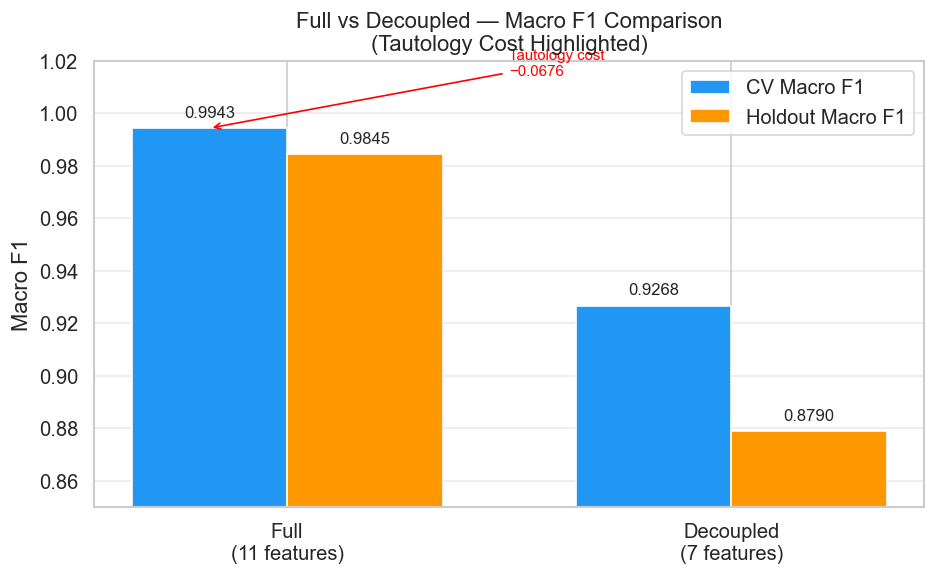

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))

models   = ['Full\n(11 features)', 'Decoupled\n(7 features)']
cv_f1    = [f1_score(y, y_pred_full, average='macro'),
            f1_score(y, y_pred_dec,  average='macro')]
ho_f1    = [f1_score(y_time_test, y_pred_full_holdout, average='macro'),
            f1_score(y_time_test, y_pred_dec_holdout,  average='macro')]

x = np.arange(len(models))
w = 0.35
bars_cv = ax.bar(x - w/2, cv_f1, w, label='CV Macro F1',      color='#2196F3')
bars_ho = ax.bar(x + w/2, ho_f1, w, label='Holdout Macro F1', color='#FF9800')

# Annotate bars
for bar in list(bars_cv) + list(bars_ho):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

# Annotate tautology cost
tautology_cost = cv_f1[0] - cv_f1[1]
ax.annotate(
    f'Tautology cost\n\u2212{tautology_cost:.4f}',
    xy=(0 - w/2, cv_f1[0]), xytext=(0.5, cv_f1[0] + 0.02),
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red', fontsize=9,
)

ax.set_ylim(0.85, 1.02)
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel('Macro F1')
ax.set_title('Full vs Decoupled — Macro F1 Comparison\n(Tautology Cost Highlighted)')
ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'macro_f1_comparison.png', dpi=150)
plt.show()

### 8.2 Per-Class F1 Comparison

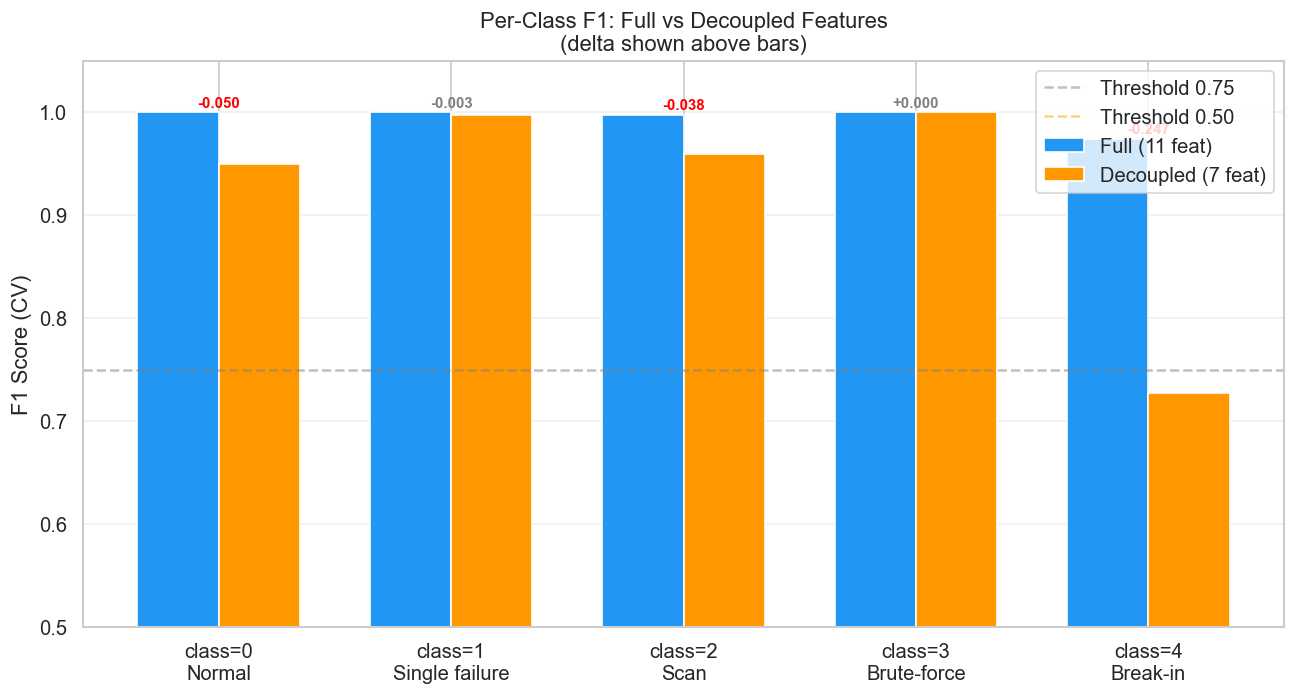

In [36]:
f1_full_cls = f1_score(y, y_pred_full, average=None)
f1_dec_cls  = f1_score(y, y_pred_dec,  average=None)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(5)
w = 0.35
ax.bar(x - w/2, f1_full_cls, w, label='Full (11 feat)', color='#2196F3')
ax.bar(x + w/2, f1_dec_cls,  w, label='Decoupled (7 feat)', color='#FF9800')

# Annotate delta cho từng class
for i in range(5):
    delta = f1_dec_cls[i] - f1_full_cls[i]
    color = 'red' if delta < -0.01 else 'green' if delta > 0.01 else 'gray'
    ax.text(i, max(f1_full_cls[i], f1_dec_cls[i]) + 0.005,
            f'{delta:+.3f}', ha='center', fontsize=9, color=color, fontweight='bold')

# Threshold lines
ax.axhline(0.75, color='gray',   linestyle='--', alpha=0.5, label='Threshold 0.75')
ax.axhline(0.50, color='orange', linestyle='--', alpha=0.5, label='Threshold 0.50')

ax.set_xticks(x)
ax.set_xticklabels([f'class={i}\n{CLASS_NAMES[i]}' for i in range(5)])
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('F1 Score (CV)')
ax.set_title('Per-Class F1: Full vs Decoupled Features\n(delta shown above bars)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_f1_comparison.png', dpi=150)
plt.show()

### 8.3 Feature Importance: Full vs Decoupled

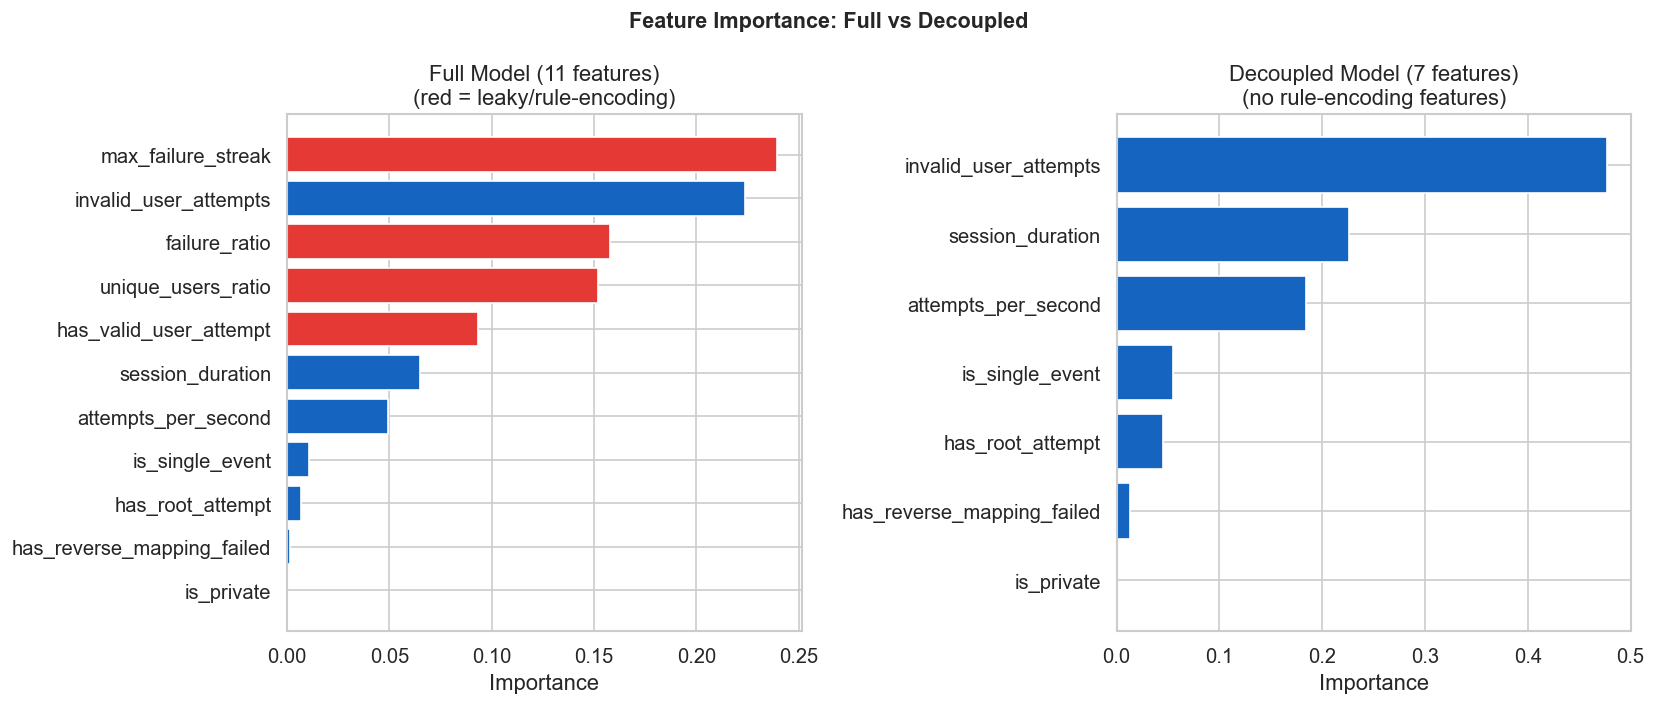

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel trái: Full model
imp_full_sorted = pd.Series(rf_full.feature_importances_,
                             index=FEATURES_FULL).sort_values()
colors_full = ['#E53935' if f in LEAKY_FEATURES else '#1565C0'
               for f in imp_full_sorted.index]
axes[0].barh(imp_full_sorted.index, imp_full_sorted.values, color=colors_full)
axes[0].set_title('Full Model (11 features)\n(red = leaky/rule-encoding)')
axes[0].set_xlabel('Importance')

# Panel phải: Decoupled model
imp_dec_sorted = pd.Series(rf_dec.feature_importances_,
                            index=FEATURES_DECOUPLED).sort_values()
axes[1].barh(imp_dec_sorted.index, imp_dec_sorted.values, color='#1565C0')
axes[1].set_title('Decoupled Model (7 features)\n(no rule-encoding features)')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance: Full vs Decoupled', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance_comparison.png', dpi=150)
plt.show()

### 8.4 Confusion Matrices (Normalized)

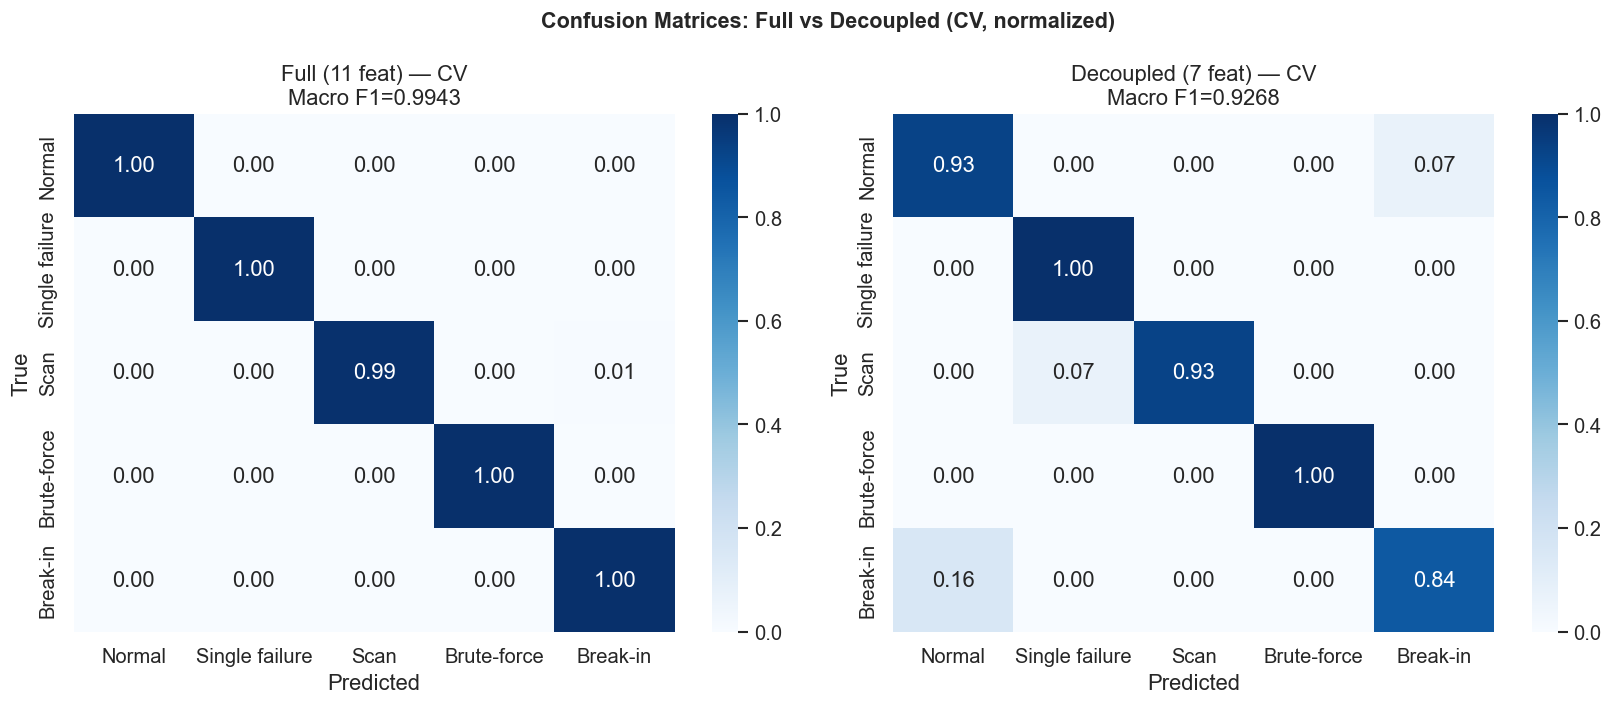

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, title in [
    (axes[0], y_pred_full, f'Full (11 feat) — CV\nMacro F1={f1_score(y,y_pred_full,average="macro"):.4f}'),
    (axes[1], y_pred_dec,  f'Decoupled (7 feat) — CV\nMacro F1={f1_score(y,y_pred_dec,average="macro"):.4f}'),
]:
    cm = confusion_matrix(y, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
                ax=ax, vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Confusion Matrices: Full vs Decoupled (CV, normalized)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_comparison.png', dpi=150)
plt.show()

---
## 9. Key Findings Summary

In [39]:
cv_full_macro  = f1_score(y, y_pred_full, average='macro')
cv_dec_macro   = f1_score(y, y_pred_dec,  average='macro')
tautology_cost = cv_full_macro - cv_dec_macro
gen_pct        = cv_dec_macro / cv_full_macro * 100
taut_pct       = tautology_cost / cv_full_macro * 100

f1_per_full = f1_score(y, y_pred_full, average=None)
f1_per_dec  = f1_score(y, y_pred_dec,  average=None)

print('=' * 65)
print('FEATURE DECOUPLING EXPERIMENT — SUMMARY')
print('=' * 65)
print(f'\n{"Metric":25s} {"Full":>10s} {"Decoupled":>10s} {"Delta":>10s}')
print('-' * 57)
print(f'{"CV Macro F1":25s} {cv_full_macro:10.4f} {cv_dec_macro:10.4f} {-tautology_cost:+10.4f}')
for cls in range(5):
    delta = f1_per_dec[cls] - f1_per_full[cls]
    print(f'{"F1 " + CLASS_NAMES[cls]:25s} {f1_per_full[cls]:10.4f} {f1_per_dec[cls]:10.4f} {delta:+10.4f}')

print(f'\n--- Interpretation ---')
print(f'Generalization:  {gen_pct:.2f}% of F1 comes from genuine patterns')
print(f'Tautology cost:  {taut_pct:.2f}% of F1 attributable to feature-label coupling')

# Highlight key insight
bf_delta = f1_per_dec[3] - f1_per_full[3]
bi_delta = f1_per_dec[4] - f1_per_full[4]
print(f'\n--- Key Insights ---')
print(f'Brute-force F1 change: {bf_delta:+.4f}  ← signal tự nhiên, không cần rule')
print(f'Break-in F1 change:    {bi_delta:+.4f}  ← phụ thuộc rule + ít data (19 samples)')

print(f'\n--- Output files ---')
for p in sorted(RESULTS_DIR.iterdir()):
    print(f'  {p.name:50s} {p.stat().st_size/1024:8.1f} KB')

FEATURE DECOUPLING EXPERIMENT — SUMMARY

Metric                          Full  Decoupled      Delta
---------------------------------------------------------
CV Macro F1                   0.9943     0.9268    -0.0676
F1 Normal                     1.0000     0.9500    -0.0500
F1 Single failure             1.0000     0.9971    -0.0029
F1 Scan                       0.9974     0.9596    -0.0378
F1 Brute-force                1.0000     1.0000    +0.0000
F1 Break-in                   0.9744     0.7273    -0.2471

--- Interpretation ---
Generalization:  93.20% of F1 comes from genuine patterns
Tautology cost:  6.80% of F1 attributable to feature-label coupling

--- Key Insights ---
Brute-force F1 change: +0.0000  ← signal tự nhiên, không cần rule
Break-in F1 change:    -0.2471  ← phụ thuộc rule + ít data (19 samples)

--- Output files ---
  comparison_summary.csv                                  0.5 KB
  confusion_matrices_comparison.png                      96.3 KB
  cv_predictions_decoupled

---
## 10. Conclusion

> **Decoupled model không thay thế Full model trong production.**
> Full model vẫn là model chính trong pipeline. Decoupling experiment chỉ phục vụ
> mục đích nghiên cứu — định lượng tautology và chứng minh generalization capacity.

**Framing cho báo cáo:**

> *"To quantify the contribution of feature-label coupling to model performance,
> we conducted a decoupling experiment by removing the four features that directly
> encode the labeling rules. The resulting model achieved a lower Macro F1,
> suggesting that a portion of the original score is attributable to
> tautological learning, while the majority reflects genuine generalization
> from indirect features. Notably, Brute-force classification remained strong
> even without its rule-encoding feature, demonstrating that this
> attack class exhibits sufficiently distinctive behavioral patterns in the
> remaining feature space."*

> *"Experiment cho thấy ~7% macro F1 đến từ feature-label coupling. Phần còn lại (0.9268) phản ánh khả năng
> generalization thực sự của model từ các features không trực tiếp encode labeling rules. Đáng chú ý, Brute-force > đạt F1=1.0 ngay cả trong điều kiện decoupled — chứng tỏ đây là class có signal tự nhiên mạnh nhất trong data."*